# **Modelo base clasificación**

## **1. Objetivo del modelo**

El objetivo del modelo es predecir el tiempo total de entrega de un pedido, definido como el intervalo temporal entre:
- el inicio del pedido por parte del repartidor (`courier_started_order_local`)
- la entrega final al cliente (`delivery_time_local`)

A diferencia del enfoque de regresión, donde se predice directamente el tiempo exacto en minutos, en este notebook el problema se formula como una tarea de clasificación multiclase.

La variable objetivo utilizada es `target_class`, que agrupa los tiempos de entrega en distintos rangos temporales:
- **Clase 0**:	5 - 20 mins
- **Clase 1**:	20 - 30 mins
- **Clase 2**:	30 - 45 mins
- **Clase 3**:	45 - 60 mins
- **Clase 4**: >=60 mins

Con el objetivo de establecer un punto de partida, se entrena un modelo base utilizando únicamente las variables originales del dataset.

Además, este baseline permitirá comparar posteriormente dos enfoques distintos para el problema de ETA (*Estimated Time of Arrival*),:
- enfoque de regresión → predicción continua en minutos y posterior discretización,
- enfoque de clasificación directa → predicción del rango temporal desde el inicio.

Esto permitirá evaluar cuál de las dos estrategias modela mejor el problema desde una perspectiva tanto técnica como de negocio.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_validate

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import make_scorer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Dataset**

Se carga el dataset previamente procesado en el notebook del modelo baseline de regresión.

La partición train_val/test ya se encuentra almacenada mediante la variable `is_test`, lo que garantiza consistencia entre experimentos y comparabilidad directa entre modelos.

In [ ]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Reto_IA/dataset_modificado_with_split.csv")

In [ ]:
df.head()

,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,saturation,distance_km,hour,day_of_week,is_weekend,day_name,target,target_min,target_class,is_test
0,Pharmacie,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,66,0.882526,9,1,0,Martes,0 days 00:30:55.658000,30.927633,2,False
1,Starbucks,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,40,0.995245,9,1,0,Martes,0 days 00:19:34.440000,19.574000,0,False
2,Starbucks,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,29,1.284852,15,1,0,Martes,0 days 00:30:23.968000,30.399467,2,False
3,NO_STORE,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,54,3.325588,10,2,0,Miércoles,0 days 00:38:46.922000,38.782033,2,False
4,Franprix,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,77,0.885714,12,2,0,Miércoles,0 days 00:27:09.774000,27.162900,1,True


### **2.1 Distribución de la variable objetivo**

Antes de entrenar el modelo, se analiza la distribución de clases de `target_class`.

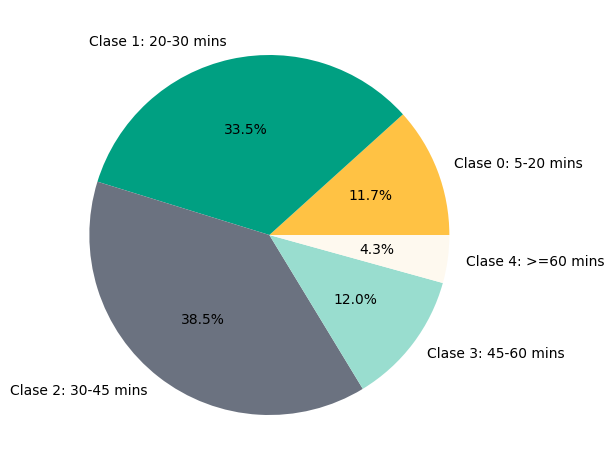

In [ ]:
glovo_palette = ['#FFC244', '#00A082', '#232323', '#99DDCF', '#FEF9EF']
glovo_palette2 = ['#FFC244', '#00A082', '#6B7280', '#99DDCF', '#FEF9EF']

labels = [
    'Clase 0: 5-20 mins',
    'Clase 1: 20-30 mins',
    'Clase 2: 30-45 mins',
    'Clase 3: 45-60 mins',
    'Clase 4: >=60 mins'
]

df.target_class.value_counts(normalize=True).sort_index().plot(
    kind='pie',
    colors=glovo_palette2,
    labels=labels,
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.tight_layout()
plt.show()

La variable objetivo presenta un desbalance moderado, con predominio de las clases intermedias (Clase 1 y 2). Esto es consistente con el comportamiento esperado en plataformas de delivery, donde la mayoría de pedidos suelen completarse en rangos temporales relativamente estables.

Sin embargo, las clases extremas presentan menor representación:
- entregas muy rápidas (Clase 0),
- y especialmente entregas muy largas (Clase 4).

Esto puede dificultar el aprendizaje del modelo, ya que existen menos ejemplos disponibles, y el algoritmo podría tender a favorecer las clases mayoritarias.

Debido al desbalance de clases métricas como accuracy pueden resultar insuficientes, ya que un modelo podría obtener buenos resultados prediciendo únicamente clases frecuentes. Por este motivo, además de accuracy se utilizarán métricas orientadas a evaluar el comportamiento del modelo en todas las clases de forma equilibrada.

## **3. Variables a eliminar**

Se eliminan variables temporales originales y variables derivadas que podrían introducir fuga de información o redundancia.

- `delivery_time_local` contiene información directa del objetivo.
- `target` y `target_min` son variables derivadas del target.
- `day_of_week` se elimina por redundancia con `day_name`.
- Las variables timestamp originales se sustituyen por variables agregadas más interpretables (`hour`, `day_name`, etc.).
- `store_name` se elimina para evitar alta cardinalidad.

In [ ]:
df_model = df.copy()

cols_drop = [
    'store_name',
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local',
    'target',
    'target_min',
    'day_of_week'
]

df_model = df_model.drop(columns=cols_drop)

In [ ]:
df_model.shape

(63589, 11)

## **4. Métricas de evaluación**

Dado que el problema consiste en clasificar pedidos en 5 rangos temporales distintos, se utilizan distintas métricas complementarias para evaluar el comportamiento del modelo desde múltiples perspectivas.

- **Accuracy**: mide el porcentaje de predicciones exactamente correctas sobre el total de observaciones. Aunque es una métrica intuitiva, presenta limitaciones importantes en datasets desbalanceados.

- **F1 Macro**: promedia el F1-score de cada clase por igual, penalizando el mal rendimiento en clases minoritarias. Esto resulta especialmente útil cuando existen clases minoritarias relevantes para negocio.

- **Precision y Recall Macro**: permiten entender si el modelo tiende a generar falsas alarmas o a perderse casos reales, evaluado de forma equitativa entre clases.

- **Métrica custom orientada a negocio**: en sistemas de ETA, no todos los errores de clasificación tienen el mismo impacto operativo. Por ejemplo, confundir una entrega de 25 minutos con una de 30 puede ser relativamente aceptable, pero clasificar una entrega extremadamente lenta como rápida puede generar una mala experiencia de usuario. Por este motivo, se define una métrica custom basada en penalizaciones asimétricas entre clases.

In [ ]:
def asymmetric_multiclass_error(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    penalty_matrix = np.array([

  # pred: 0    1    2    3    4

        [0.0, 1.0, 1.5, 2.0, 3.0],  # real = 0
        [1.0, 0.0, 1.0, 1.5, 2.5],  # real = 1
        [1.5, 1.0, 0.0, 1.0, 2.0],  # real = 2
        [2.0, 1.5, 1.0, 0.0, 1.0],  # real = 3
        [3.0, 2.5, 2.0, 1.0, 0.0]   # real = 4
    ])

    penalties = penalty_matrix[y_true, y_pred]

    return np.mean(penalties)


custom_scorer = make_scorer(
    asymmetric_multiclass_error,
    greater_is_better=False # porque menores penalizaciones representan mejor desempeño
)

# Conjunto de métricas utilizadas
scoring = {
    'custom': custom_scorer,
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

La lógica de la matriz sigue dos principios principales:
- **Penalizar más errores entre clases lejanas**: Esto refleja mejor el impacto real del error desde una perspectiva operativa.
- **Penalización simétrica respecto a la distancia**: La penalización aumenta progresivamente conforme aumenta la distancia entre clases. Esto permite modelar de forma natural que confundir categorías adyacentes es relativamente tolerable, mientras que errores extremos son considerablemente más graves.

## **5. Train, validation, test split**

Para garantizar comparabilidad entre modelos y evitar fugas de información, se reutiliza la partición previamente definida mediante la variable `is_test`.

De esta forma el conjunto de entrenamiento y validación (train_val) se utiliza para entrenamiento y selección de hiperparámetros, mientras que el conjunto de test permanece completamente aislado hasta la evaluación final.

In [ ]:
train_val_df = df_model[df_model['is_test'] == False]
test_df = df_model[df_model['is_test'] == True]

In [ ]:
X_train_val = train_val_df.drop(columns=['target_class', 'is_test'])
y_train_val = train_val_df['target_class']

X_test = test_df.drop(columns=['target_class', 'is_test'])
y_test = test_df['target_class']

## **6. Modelos evaluados**

Se entrenan tres modelos con distintos niveles de complejidad.

### **6.1 Regresión Logística**

#### **6.1.1 Definición**

En este modelo:
- las variables numéricas se escalan mediante `StandardScaler`,
- las variables categóricas se codifican con `OneHotEncoder`,
- y las binarias se mantienen sin transformación.

In [ ]:
# Pipeline de preprocesamiento
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation']
cat_cols = ['vertical', 'tranport_type', 'day_name', 'hour']
bin_cols = ['is_weekend']

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('bin', 'passthrough', bin_cols)
    ]
)

pipe_lr = Pipeline([
    ('prep', preprocessor_lr),
    ('model', LogisticRegression())
])

pipe_lr

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['gtv', 'delivery_fee',
                                                   'distance_km',
                                                   'saturation']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vertical', 'tranport_type',
                                                   'day_name', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['is_weekend'])])),
                ('model', LogisticRegression())])

#### **6.1.2 Cross-validation**

Se utiliza validación cruzada con 5 folds.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluación del modelo
results_lr = cross_validate(
    pipe_lr,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring
)

# Resultados
acc_lr = results_lr['test_accuracy'].mean()
f1_lr = results_lr['test_f1_macro'].mean()
pm_lr = results_lr['test_precision_macro'].mean()
custom_lr = results_lr['test_custom'].mean()

print("ACCURACY:", acc_lr )
print("F1:", f1_lr)
print("PRECISION MACRO:", pm_lr)
print("CUSTOM:", abs(custom_lr))


ACCURACY: 0.5067129518853521
F1: 0.3994398264410691
PRECISION MACRO: 0.5075529505802181
CUSTOM: 0.5253977074095022


La Regresión Logística consigue resultados razonables considerando su simplicidad. Sin embargo, el F1 Macro relativamente bajo sugiere dificultades para modelar correctamente todas las clases, especialmente las minoritarias.

Esto era esperable debido a que el problema presenta relaciones no lineales,
interacciones complejas, y posibles efectos contextuales difíciles de representar mediante fronteras lineales.

### **6.2 Random Forest**

#### **6.2.1 Definición**

Random Forest es un modelo ensemble basado en múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos y variables.

Su principal ventaja es que reduce varianza respecto a un único árbol,
captura relaciones no lineales, y maneja bien interacciones entre variables.

En Random Forest no se aplica escalado a las variables numéricas, ya que los algoritmos basados en árboles no son sensibles a la escala de los datos, al basarse en reglas de partición y no en distancias.

In [ ]:
# Pipeline de preprocesamiento
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation', 'hour']
cat_cols = ['vertical', 'tranport_type', 'day_name']
bin_cols = ['is_weekend']

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough')

pipe_rf = Pipeline([
    ('prep', preprocessor_rf),
    ('model', RandomForestClassifier(random_state=42))
])

#### **6.2.2 Grid search y cross-validation**

Se realiza búsqueda de hiperparámetros mediante `GridSearchCV`.

Los hiperparámetros explorados fueron:
- **`max_depth`**: controla la profundidad máxima de los árboles.
- **`min_samples_split`**: cantidad mínima de observaciones necesarias para dividir un nodo.
- **`min_samples_leaf`**: cantidad mínima de observaciones permitidas en una hoja terminal.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Entrenamiento
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring=scoring,
    refit='custom',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['vertical',
                                                                          'tranport_type',
                                                                          'day_name'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100]},
             refit='custom',
             scoring={'accuracy': 'accuracy',
                      'custom': make_scorer(asymmetric_multiclass_error, greater_is_better=False, response_method='predict'),
                      'f1_macro': 'f1_macro',
                      'precision_macro': 'precision_macro',
                      'recall_macro': 'recall_macro'},
             verbose=2)

**Mejores hiperparámetros**

In [ ]:
grid_rf.best_params_

{'model__max_depth': 10,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [ ]:
# Mejor score custom
grid_rf.best_score_

np.float64(-0.523441727697281)

In [ ]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

results_rf[[
    'params',
    'mean_test_custom',
    'mean_test_accuracy',
    'mean_test_f1_macro',
    'mean_test_precision_macro',
    'mean_test_recall_macro'
]]

,params,mean_test_custom,mean_test_accuracy,mean_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro
0,"{'model__max_depth': 10, 'model__min_samples_l...",-0.523442,0.509288,0.373069,0.555765,0.369182
1,"{'model__max_depth': 10, 'model__min_samples_l...",-0.525083,0.508128,0.371008,0.538063,0.366852
2,"{'model__max_depth': 10, 'model__min_samples_l...",-0.523658,0.509308,0.372783,0.557316,0.368517
3,"{'model__max_depth': 10, 'model__min_samples_l...",-0.524012,0.509210,0.372151,0.545365,0.368362
4,"{'model__max_depth': 20, 'model__min_samples_l...",-0.548751,0.492402,0.405839,0.464629,0.389202
5,"{'model__max_depth': 20, 'model__min_samples_l...",-0.539718,0.498319,0.409902,0.476763,0.392911
6,"{'model__max_depth': 20, 'model__min_samples_l...",-0.538254,0.499735,0.405989,0.477040,0.389835
7,"{'model__max_depth': 20, 'model__min_samples_l...",-0.536160,0.501130,0.406988,0.478681,0.391534


In [ ]:
results_rf.to_csv("results_rf.csv", index=False)

Los resultados muestran que aumentar demasiado la profundidad mejora ligeramente F1, pero empeora la métrica custom.

Esto indica que modelos más complejos generan errores más severos entre clases lejanas.

### **6.3 XGBoost**

#### **6.3.1 Definición**

XGBoost es un algoritmo de gradient boosting basado en árboles de decisión.

A diferencia de Random Forest, los árboles se entrenan secuencialmente,
corrigiendo iterativamente los errores previos.

Esto permite capturar patrones complejos, modelar relaciones no lineales,
y obtener alto rendimiento en problemas tabulares.

In [ ]:
# Pipeline de preprocesamiento: Al igual que Random Forest, no requiere escalado numérico
num_cols = ['gtv', 'delivery_fee', 'distance_km', 'saturation', 'hour']
cat_cols = ['vertical', 'tranport_type', 'day_name']
bin_cols = ['is_weekend']

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough')

pipe_xgb = Pipeline([
    ('prep', preprocessor_xgb),
    ('model', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

#### **6.3.2 Grid search y cross-validation**

Los hiperparámteros explorados fueron:

- **`max_depth`**: controla la profundidad máxima de los árboles.
- **`learning_rate`**: controla la velocidad de aprendizaje del boosting.
- **`subsample`**: controla el porcentaje de observaciones utilizadas en cada árbol.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_xgb = {
    'model__n_estimators': [200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

# Entrenamiento
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring=scoring,
    refit='custom',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train_val, y_train_val)

# Mejores hiperparámetros
print(grid_xgb.best_params_)
print("Best custom score:", grid_xgb.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best custom score: -0.5190581406862123


In [ ]:
# Convertimos los resultados del GridSearch a DataFrame
results_xgb = pd.DataFrame(grid_xgb.cv_results_)

results_xgb[[
    'params',
    'mean_test_custom',
    'mean_test_accuracy',
    'mean_test_f1_macro',
    'mean_test_recall_macro'
]].sort_values('mean_test_custom', ascending=False) # Mayor valor (menos negativo) es mejor

,params,mean_test_custom,mean_test_accuracy,mean_test_f1_macro,mean_test_recall_macro
2,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.519058,0.514832,0.421664,0.409848
7,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.519363,0.514596,0.420122,0.410137
6,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.519373,0.514438,0.422408,0.411332
3,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.519569,0.514281,0.417894,0.407472
0,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.519982,0.513514,0.408320,0.404964
1,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.520316,0.513397,0.406118,0.404396
9,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.522606,0.512001,0.422284,0.408837
4,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.522960,0.511961,0.425013,0.410687
5,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.523353,0.511706,0.421129,0.408530
8,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.524149,0.511175,0.422909,0.408896


In [ ]:
results_xgb.to_csv("results_xgb.csv", index=False)

El modelo óptimo utiliza learning rate bajo, árboles de profundidad moderada,
y subsampling. Esto sugiere que el problema requiere capacidad no lineal,
pero modelos excesivamente complejos generan sobreajuste.

## **7. Comparación de modelos**

In [ ]:
results_rf = pd.read_csv("results_rf.csv")
results_xgb = pd.read_csv("results_xgb.csv")

In [ ]:
best_rf = results_rf.loc[grid_rf.best_index_]
best_xgb = results_xgb.loc[grid_xgb.best_index_]

summary_results = pd.DataFrame({
    'Modelo': [
        'Regresión Logistica',
        'Random Forest',
        'XGBoost'
    ],

    'F1': [
        f1_lr,
        best_rf['mean_test_f1_macro'],
        best_xgb['mean_test_f1_macro']
    ],

    'ACCURACY': [
        pm_lr,
        best_rf['mean_test_accuracy'],
        best_xgb['mean_test_accuracy']
    ],

    'CUSTOM': [
        abs(custom_lr),
        -best_rf['mean_test_custom'],
        -best_xgb['mean_test_custom']
    ]
})

summary_results = summary_results.round(3)

summary_results

,Modelo,F1,ACCURACY,CUSTOM
0,Regresión Logistica,0.399,0.508,0.525
1,Random Forest,0.373,0.509,0.523
2,XGBoost,0.422,0.515,0.519


XGBoost obtiene el mejor rendimiento global entre los modelos evaluados:
- mayor F1 Macro,
- mayor Accuracy,
- y menor error custom.

Esto indica que el modelo logra un mejor equilibrio entre clases,
y reduce errores severos entre categorías alejadas.

Sin embargo, la mejora respecto a Random Forest es relativamente moderada (F1 Macro: +0.049, Accuracy: +0.006, Custom: -0.004), lo que sugiere que el modelo  está limitado principalmente por la información disponible en las variables y no únicamente por la complejidad del algoritmo.

Por otro lado, los modelos basados en árboles superan a la Regresión Logística en F1 Macro y métrica custom. Esto confirma que el problema contiene relaciones no lineales, interacciones complejas, y patrones difíciles de capturar mediante fronteras lineales.

Sin embargo, la Accuracy de la Regresión Logística sigue siendo relativamente competitiva, lo que indica que las clases mayoritarias son parcialmente separables incluso con modelos simples.

## **8. Evaluación final en conjunto de test**

- **Selección del modelo final**

Tras comparar los distintos modelos mediante validación cruzada, se selecciona XGBoost como modelo final, al obtener el mejor rendimiento global en las tres métricas evaluadas.

- **Reentrenamiento del modelo final**

Una vez seleccionado el mejor conjunto de hiperparámetros, el modelo se reentrena utilizando todo el conjunto de entrenamiento-validación (`train_val`) para aprovechar al máximo la información disponible antes de la evaluación final.

In [ ]:
best_xgb = grid_xgb.best_estimator_

best_xgb.fit(X_train_val, y_train_val)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vertical', 'tranport_type',
                                                   'day_name'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

- **Evaluación en conjunto de test**

Finalmente, el modelo se evalúa sobre el conjunto de test, que permaneció completamente separado durante todo el proceso de entrenamiento y selección de modelos.

In [ ]:
# Predicciones en test
y_pred = best_xgb.predict(X_test)

# Evaluar métricas
accuracy_test  = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='macro')
precision_test = precision_score(y_test, y_pred, average='macro')
recall_test = recall_score(y_test, y_pred, average='macro')
custom_test = asymmetric_multiclass_error(y_test, y_pred)

print("TEST ACCURACY: ", round(accuracy_test, 3))
print("TEST F1 MACRO:", round(f1_test, 3))
print("TEST PRECISION:", round(precision_test, 3))
print("TEST RECALL:   ", round(recall_test, 3))
print("TEST CUSTOM:   ", round(custom_test, 3))

TEST ACCURACY:  0.521
TEST F1 MACRO: 0.418
TEST PRECISION: 0.501
TEST RECALL:    0.404
TEST CUSTOM:    0.51


Los resultados en test son consistentes con los obtenidos en validación cruzada, lo que indica que el modelo generaliza correctamente y no presenta sobreajuste relevante.

- **Feature importance**

La importancia de variables obtenida en el modelo de clasificación permite identificar qué features contribuyen en mayor medida a predecir directamente el rango temporal de entrega.

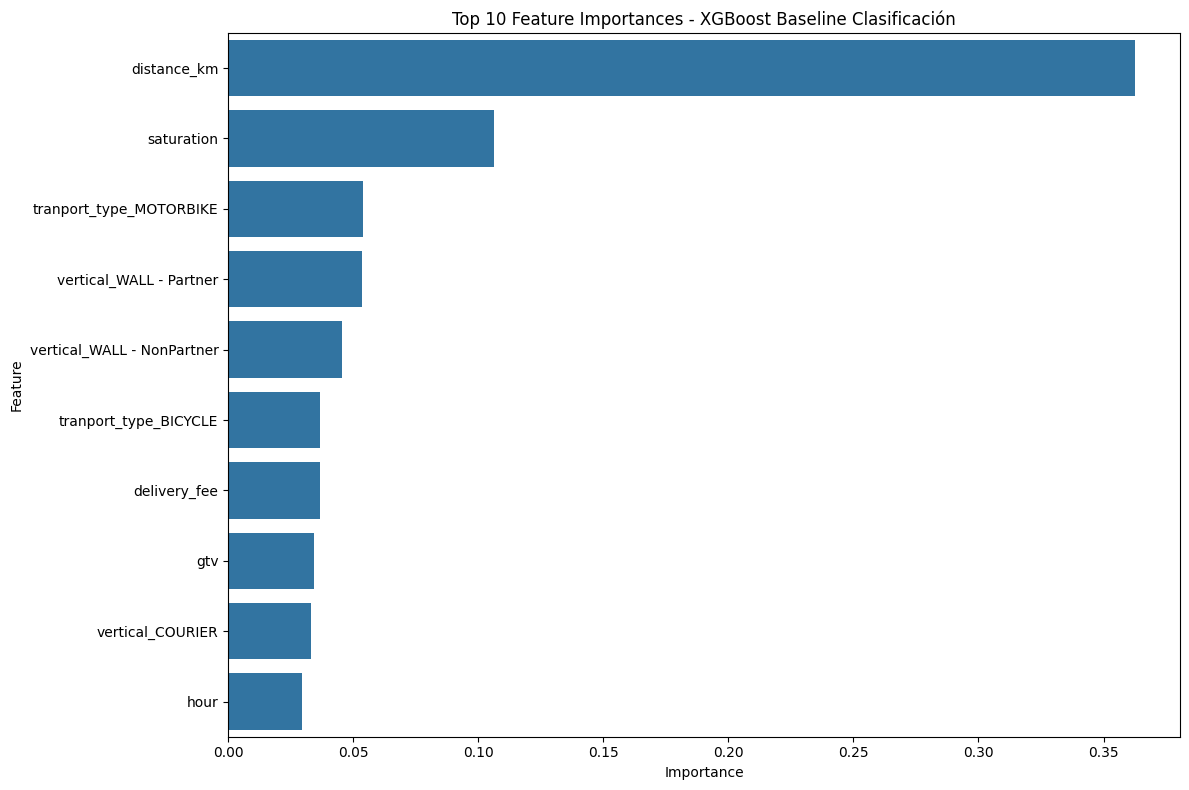

In [ ]:
# Obtenemos el modelo entrenado
model = best_xgb.named_steps['model']

# Nombres features
prep = best_xgb.named_steps['prep']

# Features generadas por OneHotEncoder
ohe_features = prep.named_transformers_['cat'].get_feature_names_out(cat_cols)

# Features numéricas + binarias que pasan por remainder='passthrough'
all_features = list(ohe_features) + num_cols + bin_cols

# Importancias
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=feat_imp.head(10),
    x='importance',
    y='feature'
)

plt.title('Top 10 Feature Importances - XGBoost Baseline Clasificación')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
top10_feat_imp = (
    feat_imp[['feature', 'importance']]
    .sort_values(by='importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_feat_imp['importance'] = top10_feat_imp['importance'].round(4)

print(top10_feat_imp)

                      feature  importance
0                 distance_km      0.3624
1                  saturation      0.1061
2     tranport_type_MOTORBIKE      0.0541
3     vertical_WALL - Partner      0.0537
4  vertical_WALL - NonPartner      0.0454
5       tranport_type_BICYCLE      0.0369
6                delivery_fee      0.0366
7                         gtv      0.0345
8            vertical_COURIER      0.0330
9                        hour      0.0294


El modelo base de clasificación confirma los patrones observados previamente en el enfoque de regresión. Las variables operativas continúan siendo los principales drivers predictivos, especialmente `distance_km` y `saturation`, que concentran gran parte de la capacidad explicativa del modelo.

Además, el enfoque de clasificación parece otorgar algo más de relevancia relativa a variables categóricas como el tipo de transporte o la vertical, probablemente porque estas ayudan a separar mejor los distintos rangos temporales.

- **Classification report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.09      0.15      1464
           1       0.50      0.63      0.56      4266
           2       0.56      0.64      0.59      4974
           3       0.45      0.27      0.34      1478
           4       0.53      0.38      0.44       536

    accuracy                           0.52     12718
   macro avg       0.50      0.40      0.42     12718
weighted avg       0.51      0.52      0.50     12718



- **Matriz de confusión**

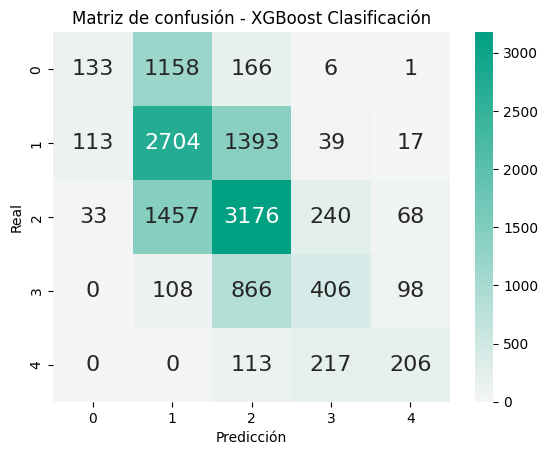

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

GLOVO_COLORS = {
    "green":      "#00A082",
    "yellow":     "#FFC244",
    "gray_dark":  "#333333",
    "gray_light": "#F5F5F5",
}

glovo_cmap = LinearSegmentedColormap.from_list(
    "glovo_green", [GLOVO_COLORS["gray_light"], GLOVO_COLORS["green"]]
)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=glovo_cmap, annot_kws={"size": 16},
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - XGBoost Clasificación')
plt.show()

La matriz de confusión muestra que el modelo presenta un mejor desempeño en las clases intermedias (1 y 2), que corresponden además a las categorías con mayor cantidad de observaciones. En contraste, las clases extremas (0 y 4) presentan menor capacidad de detección, siendo frecuentemente clasificadas en categorías vecinas.

La mayoría de los errores ocurre entre clases contiguas, lo cual resulta consistente con la naturaleza del problema, ya que el objetivo es predecir intervalos de tiempo de entrega. Esto indica que el modelo logra aproximar la duración del pedido, aunque presenta dificultades para distinguir correctamente los casos más rápidos y más lentos.

## **9. Comparación con el modelo baseline de regresión**

Con el objetivo de evaluar qué enfoque resulta más adecuado para el problema de predicción de tiempos de entrega, se compararon los dos enfoques distintos:
- Modelo de clasificación directa: predice directamente la categoría de tiempo de entrega.
- Modelo de regresión + discretización: predice el tiempo exacto en minutos y posteriormente transforma la predicción continua en categorías.

Aunque ambos enfoques terminan generando clases discretas comparables, el criterio de optimización durante el entrenamiento fue diferente:
- el modelo de regresión fue optimizado sobre métricas continuas de error temporal,
- mientras que el modelo de clasificación fue optimizado directamente sobre métricas multiclase.

Por ello, la comparación se centra principalmente en el comportamiento final sobre las clases predichas.

**Comparación de resultados**

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Baseline regresión + discretización',
        'Clasificación directa'
    ],

    'Accuracy': [
        0.51,
        0.52
    ],

    'F1 Macro': [
        0.39,
        0.42
    ]
})

comparacion

,Modelo,Accuracy,F1 Macro
0,Baseline regresión + discretización,0.51,0.39
1,Clasificación directa,0.52,0.42


El modelo de clasificación directa obtiene un rendimiento ligeramente superior al baseline de regresión discretizado, especialmente en F1 Macro, lo que indica un mejor equilibrio entre clases.

La mejora, sin embargo, es moderada:
- Accuracy: +1 punto porcentual.
- F1 Macro: +0.03.

Esto sugiere que, utilizando únicamente las variables originales del dataset, ambos enfoques presentan limitaciones similares en capacidad predictiva.

Si analizamos las matrices de confusión obtenidas, ambos modelos presentan un comportamiento parecido:
- mejor rendimiento en las clases intermedias (1 y 2),
- dificultades para detectar correctamente las clases extremas,
- errores concentrados principalmente entre clases vecinas.

Sin embargo, el modelo de clasificación directa logra una mejora en la detección de la clase 0 (entregas rápidas):
- **Recall clase 0 Regresión discretizada**: 0.02
- **Recall clase 0 Clasificación directa**: 0.09

El baseline de regresión muestra una fuerte tendencia a desplazar predicciones hacia las clases centrales, especialmente hacia la clase 1, lo que provoca una infra-detección de entregas muy rápidas.

En ambos enfoques, la clase 4 continúa siendo difícil de modelar debido a su baja representación en el dataset.

## **10. Conclusiones**

A nivel baseline, el enfoque de clasificación directa muestra un rendimiento ligeramente superior al enfoque de regresión discretizada. Sin embargo, las diferencias entre ambos modelos son reducidas y ambos presentan limitaciones similares, especialmente en la detección de clases extremas.

Además, el análisis de *feature importance* evidencia que gran parte de la capacidad predictiva se concentra en un número reducido de variables operativas, principalmente `distance_km` y `saturation`. Esto sugiere que el principal límite del rendimiento actual no se encuentra únicamente en el tipo de modelado utilizado, sino también en la información disponible en las *features* originales.

Por ello, el siguiente paso del proyecto consiste en realizar una fase de *feature engineering* aplicada tanto al modelo de regresión como al de clasificación, con el objetivo de incorporar nuevas señales que permitan capturar mejor la complejidad operativa del problema y comparar nuevamente ambos enfoques bajo una representación más rica de los datos.